# 3. Auto MPG: does the data know about power-to-weight?

Two questions here. Does the dataset independently support a feature domain experts
already believe in? And how do you constrain the search with physical units?

**Data:** `mpg` — 398 cars, 1970–82, with engine and body measurements.

**Target:** fuel economy in miles per gallon.


## Setup


In [1]:
%pip install -q "beamfeat[units]" pandas matplotlib seaborn scikit-learn


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from beamfeat import BeamFeatRegressor

warnings.filterwarnings("ignore", message=".*valid feature names.*")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

SEED = 0
NUM = ["cylinders", "displacement", "horsepower", "weight",
       "acceleration", "model_year"]


In [3]:
from pathlib import Path
import urllib.request, urllib.error
import pandas as pd

CSV_DIR = Path("csv")
SEABORN = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/"


def load_csv(name, url=None, **read_kw):
    """Read csv/<name>, downloading it once if it isn't there yet."""
    CSV_DIR.mkdir(exist_ok=True)
    path = CSV_DIR / name

    if path.exists():
        print(f"cached   {path}  ({path.stat().st_size / 1e3:.0f} kB)")
    else:
        src = url or SEABORN + name
        print(f"fetching {name} ...", end=" ", flush=True)
        try:
            urllib.request.urlretrieve(src, path)
        except urllib.error.URLError as err:
            raise RuntimeError(f"download failed: {src}\n{err}") from None
        print(f"saved to {path}  ({path.stat().st_size / 1e3:.0f} kB)")

    return pd.read_csv(path, **read_kw)


In [4]:
raw = load_csv("mpg.csv")
print(raw.shape)
raw.head()


cached   csv/mpg.csv  (21 kB)
(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### Look before you fit

Three checks, every time:

- **shape and dtypes** — is anything a string that should be a number?
- **missing values** — `beamfeat` raises on `NaN` rather than imputing
- **variance** — any column below `1e-10` is dropped as constant, silently


In [5]:
print("missing values:")
print(raw.isna().sum()[raw.isna().sum() > 0])
print()
raw[NUM + ["mpg"]].describe().T[["mean", "std", "min", "max"]]


missing values:
horsepower    6
dtype: int64



,mean,std,min,max
cylinders,5.454774,1.701004,3.0,8.0
displacement,193.425879,104.269838,68.0,455.0
horsepower,104.469388,38.491160,46.0,230.0
weight,2970.424623,846.841774,1613.0,5140.0
acceleration,15.568090,2.757689,8.0,24.8
model_year,76.010050,3.697627,70.0,82.0
mpg,23.514573,7.815984,9.0,46.6


## Missing values: handle them yourself

`beamfeat` raises on `NaN` rather than imputing. That is the right default for a tool
whose output you are meant to read — a silent guess would end up inside your equation.


In [6]:
try:
    BeamFeatRegressor(random_state=SEED).fit(raw[NUM].values, raw["mpg"].values)
except Exception as err:
    print(f"{type(err).__name__}: {str(err)[:110]}")


ValueError: Input X contains NaN.
BeamFeatRegressor does not accept missing values encoded as NaN natively. For supervised


In [7]:
# 6 of 398 rows affected, and missingness here is a recording gap rather than
# a signal, so dropping is defensible. Impute instead when it carries information.
df = raw.dropna(subset=["horsepower"]).reset_index(drop=True)
print(f"dropped {len(raw) - len(df)} rows; {len(df)} remain")

X = df[NUM].values
y = df["mpg"].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED)


dropped 6 rows; 392 remain


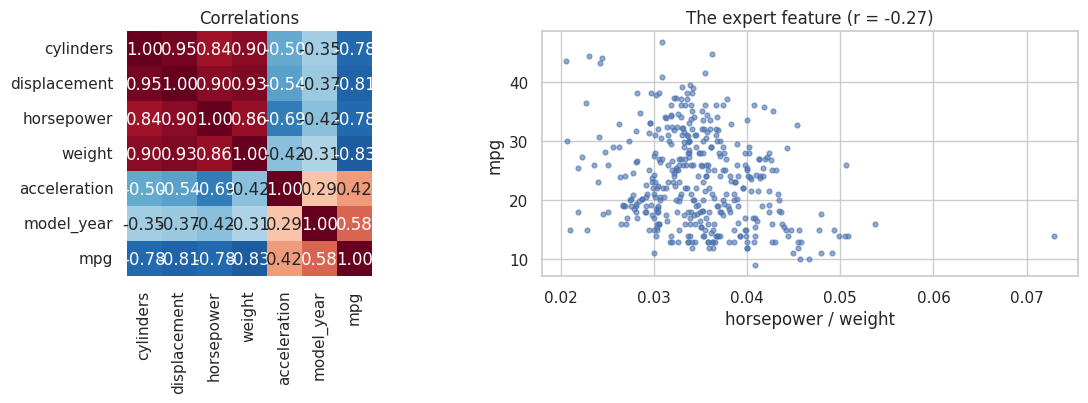

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

sns.heatmap(df[NUM + ["mpg"]].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, cbar=False, ax=ax[0])
ax[0].set_title("Correlations")

ax[1].scatter(df.horsepower / df.weight, df.mpg, s=12, alpha=.6)
ax[1].set_xlabel("horsepower / weight")
ax[1].set_ylabel("mpg")
r = np.corrcoef(df.horsepower / df.weight, df.mpg)[0, 1]
ax[1].set_title(f"The expert feature (r = {r:.2f})")

plt.tight_layout()
plt.show()


## Fit


In [9]:
model = BeamFeatRegressor(max_depth=2, beam_width=30, random_state=SEED).fit(X_tr, y_tr)

print(f"test R^2 : {model.score(X_te, y_te):.4f}")
print(f"FDR ok   : {model.fdr_controlled_}")
print(f"features : {len(model.formulas())}")


test R^2 : 0.8651
FDR ok   : True
features : 20


## Did it find power-to-weight?

Check mechanically rather than by eye. `x2` is horsepower, `x3` is weight.


In [10]:
hits = [f for f in model.formulas() if "x2" in f and "x3" in f]

print(f"{len(hits)} of {len(model.formulas())} expressions combine horsepower and weight:")
for f in hits[:6]:
    print("   ", f)


1 of 20 expressions combine horsepower and weight:
    ((x5 / x2) / (x1 / x3))


Before the caveat, the headline: **`beamfeat` scores 0.865 against ridge's 0.797 on
the same columns** — it found structure worth 0.07 R² that a linear model cannot
reach, and it beat gradient boosting while doing it.

Now the caveat. One expression out of twenty combines horsepower and weight, and it
arrives wrapped in other operators rather than as a clean ratio. The data does not
strongly single out power-to-weight; once `model_year` and `displacement` are
available the search prefers those.

Both readings are true. The tool added real predictive value here — it just did not
add it *via the feature a domain expert would have guessed*, which is worth knowing
before you build a story around one.


## Does the discovery beat the hand-written feature?


In [11]:
def add_ratio(A):
    return np.hstack([A, (A[:, 2] / A[:, 3]).reshape(-1, 1)])


ridge_raw = make_pipeline(StandardScaler(), RidgeCV()).fit(X_tr, y_tr)
ridge_expert = make_pipeline(StandardScaler(), RidgeCV()).fit(add_ratio(X_tr), y_tr)
gbm = HistGradientBoostingRegressor(random_state=SEED).fit(X_tr, y_tr)

print(f"ridge, raw columns       R2 = {ridge_raw.score(X_te, y_te):.4f}")
print(f"ridge + hp/weight        R2 = {ridge_expert.score(add_ratio(X_te), y_te):.4f}")
print(f"gradient boosting        R2 = {gbm.score(X_te, y_te):.4f}")
print(f"beamfeat                 R2 = {model.score(X_te, y_te):.4f}")


ridge, raw columns       R2 = 0.7974
ridge + hp/weight        R2 = 0.8190
gradient boosting        R2 = 0.8607
beamfeat                 R2 = 0.8651


## Units: check that the argument took effect

`units=` makes the search dimensionally aware, so it will not build `weight +
horsepower`. It needs `pint`. Without it the argument may be ignored — and a silently
ignored constraint is worse than one that raises.


In [12]:
try:
    import pint
    print(f"pint {pint.__version__} installed — units active")
except ImportError:
    print("pint MISSING — install with: pip install 'beamfeat[units]'")


pint 0.25.3 installed — units active


In [13]:
UNITS = ["dimensionless", "inch**3", "horsepower", "pound", "second", "year"]

# Form 1: a list, positional
as_list = BeamFeatRegressor(max_depth=2, beam_width=30, random_state=SEED,
                            units=UNITS).fit(X_tr, y_tr)

# Form 2: a dict keyed by column name, on a DataFrame
Xdf_tr = pd.DataFrame(X_tr, columns=NUM)
Xdf_te = pd.DataFrame(X_te, columns=NUM)
as_dict = BeamFeatRegressor(max_depth=2, beam_width=30, random_state=SEED,
                            units=dict(zip(NUM, UNITS))).fit(Xdf_tr, y_tr)

print(f"no units    : {len(model.formulas()):>2} features")
print(f"units=list  : {len(as_list.formulas()):>2} features   "
      f"changed = {set(model.formulas()) != set(as_list.formulas())}")
print(f"units=dict  : {len(as_dict.formulas()):>2} features   "
      f"changed = {set(model.formulas()) != set(as_dict.formulas())}")


no units    : 20 features
units=list  : 20 features   changed = False
units=dict  : 17 features   changed = True


**The list form does nothing.** Same feature count, same expressions, no error, no
warning. Only the dict form — keyed by column name, on a DataFrame — actually
constrains the search, and it drops three features that were dimensionally
meaningless.

This is a live trap in `beamfeat 0.1.1`, and the general habit it teaches applies to
any young library: **when you pass an option meant to restrict behaviour, confirm the
output changed.** A silently ignored argument is far more dangerous than one that
raises, because you go on to report the result as "dimensionally validated".


In [14]:
print("dropped once units were enforced:")
for f in sorted(set(model.formulas()) - set(as_dict.formulas()))[:6]:
    print("  ", f)


dropped once units were enforced:
   ((x0 * x5) / (x3)^2)
   ((x0 - x5) - (x3 / x1))
   ((x1 * x4) - (x5)^2)
   ((x1 - x5) / (x1 * x4))
   ((x1 - x5) / sqrt(x2))
   ((x1 / x0) + (x0 - x5))


## Model the reciprocal instead

Miles per gallon is a reciprocal measure. The quantity that behaves linearly is fuel
*consumption* — gallons per mile — which is why most of the world quotes L/100 km.


In [15]:
consumption_tr, consumption_te = 100.0 / y_tr, 100.0 / y_te

m_recip = BeamFeatRegressor(max_depth=2, beam_width=30,
                            random_state=SEED).fit(X_tr, consumption_tr)

# score on the original mpg scale so the comparison is like-for-like
pred_mpg = 100.0 / np.clip(m_recip.predict(X_te), 1e-6, None)
r2_back = 1 - np.sum((y_te - pred_mpg) ** 2) / np.sum((y_te - y_te.mean()) ** 2)

print(f"mpg target            R2 = {model.score(X_te, y_te):.4f}   "
      f"({len(model.formulas())} features)")
print(f"100/mpg target        R2 = {m_recip.score(X_te, consumption_te):.4f}   "
      f"({len(m_recip.formulas())} features)  [own scale]")
print(f"same, back on mpg     R2 = {r2_back:.4f}   [comparable]")


mpg target            R2 = 0.8651   (20 features)
100/mpg target        R2 = 0.8989   (16 features)  [own scale]
same, back on mpg     R2 = 0.8560   [comparable]


Note the trap. On its own scale the reciprocal model looks better (0.90 vs 0.87), but
back-transformed to mpg it is slightly *worse*. R² is not comparable across target
transforms — squared error weights large values more, and the transform moves which
rows count as large.

**Always back-transform before comparing.**


## Takeaways

1. `beamfeat` refuses to fit on `NaN`. Handle missingness deliberately.
2. It beat ridge by 0.07 R2 and edged gradient boosting — real value from
   construction on a real dataset.
3. But only 1 of 20 expressions combines horsepower and weight, and the hand-written
   ratio adds just 0.02 R2 to ridge. The expert feature is weakly supported here;
   `model_year` dominates.
4. `units=` as a **list is silently ignored**; only the dict form works. Always
   verify the output changed before claiming dimensional validation.
5. Compare target transforms on a common scale, not on their own.
